In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [26]:
def cortisol(stress_level,I):
    #variables
    v_rest=-70 #resting potential (mV)
    v_threshold=-55+(stress_level*15) #firing threshold (mV)
    v_reset=-70 #reset potential (mV)
    tau=20 #time constant (ms)
    R=1 #membrane resistance
    dt=0.1 #time step (ms)
    t_total=200 #total simulation time (ms)
    refractory=5 #refractory period duration (ms)
    #for starting point
    vm=v_rest 
    refractory_count=0
    spike_list=[]
    voltage_list=[]
    for t in np.arange(0,t_total,dt):
        voltage_list.append(vm)
        if refractory_count>0:
            refractory_count=refractory_count-dt
            continue
        dvm_dt=(-(vm-v_rest)+R*I)/tau
        vm=vm+dt*dvm_dt
        if vm>=v_threshold:
            spike_list.append(t)
            vm=v_reset
            refractory_count=refractory
    return voltage_list,spike_list
A_pattern = np.array([
    [-1,+1,+1,+1,+1,+1,+1,+1,+1,-1],
    [+1,-1,-1,-1,-1,-1,-1,-1,-1,+1],
    [+1,-1,-1,-1,-1,-1,-1,-1,-1,+1],
    [+1,+1,+1,+1,+1,+1,+1,+1,+1,+1],
    [+1,-1,-1,-1,-1,-1,-1,-1,-1,+1],
    [+1,-1,-1,-1,-1,-1,-1,-1,-1,+1],
    [+1,-1,-1,-1,-1,-1,-1,-1,-1,+1],
    [-1,-1,-1,-1,-1,-1,-1,-1,-1,-1],
    [-1,-1,-1,-1,-1,-1,-1,-1,-1,-1],
    [-1,-1,-1,-1,-1,-1,-1,-1,-1,-1],
]) #the pattern
N=100 #number of neuron
x = A_pattern.flatten()
stresslevels=[0.0,0.3,0.5,0.7,0.8,0.9,1.0]
colors = ['blue', 'green', 'orange', 'red', 'purple']
results={}
np.random.seed(42)
memory_results={}
accuracy_list=[]
w_dict={}
for i in stresslevels:
    voltage_list,spike_list=cortisol(i,20)
    results[i]=(voltage_list,spike_list)
    W_base = (1/N) * np.outer(x, x)
    np.fill_diagonal(W_base, 0)

    noise = np.random.randn(N, N) * i
    noise = (noise + noise.T) / 2
    np.fill_diagonal(noise, 0)
    s=x.copy()
    W = (1 - i) * W_base + noise * 0.02
    w_dict[i]=W
    wrong_index=np.random.choice(100,35,replace=False)
    s[wrong_index]*=-1
    for k in range(20):
        s_new=np.sign(W @ s)
        s_new[s_new==0]=1
        if np.array_equal(s_new,s):
            break
        s=s_new
    accuracy=np.sum(x==s)/N*100
    memory_results[i]=s.reshape(10,10)
    accuracy_list.append(accuracy)
    print(f"accuracy:{accuracy:.1f}%")     
dt = 0.1
t_total = 200
time_list = np.arange(0, t_total, dt)
time_list=np.arange(0,t_total,dt)

accuracy:100.0%
accuracy:100.0%
accuracy:100.0%
accuracy:99.0%
accuracy:94.0%
accuracy:66.0%
accuracy:60.0%


In [ ]:
plt.figure(figsize=(12,5))
for i, color in zip(stresslevels, colors):
    voltage_list, spike_list = results[i]
    v_threshold = -55 + (i * 15)
    plt.plot(time_list, voltage_list, color=color, 
             label=f'Stress={i} | Threshold={v_threshold:.1f}mV | Spike={len(spike_list)}')
plt.axhline(y=-70,color="green",linestyle="--",label="V_rest(-70mV)")
plt.xlabel("Time(ms)")
plt.ylabel("Voltage(mV)")
plt.title("LIF Neuron — Voltage Plot")

plt.legend()
plt.tight_layout()
plt.show() 

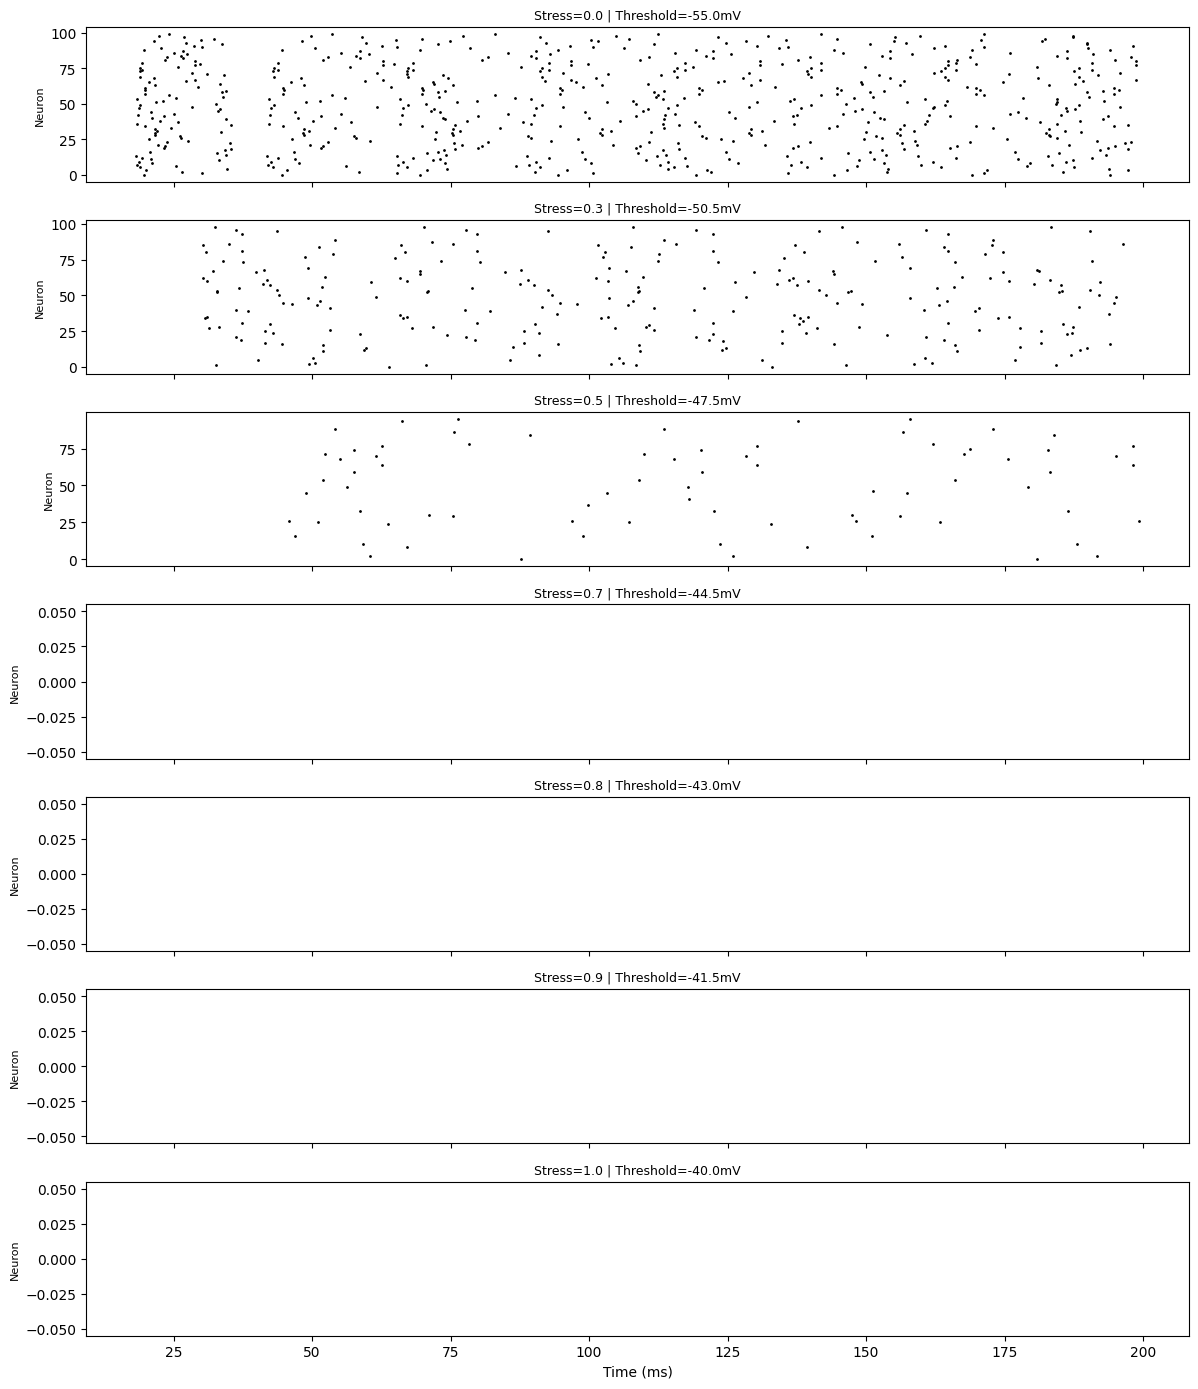

In [6]:
fig, axes = plt.subplots(len(stresslevels), 1, figsize=(12, 14), sharex=True)

for idx, stress in enumerate(stresslevels):
    ax = axes[idx]
    for neuron in range(N):
        I = np.random.uniform(18, 25)
        voltage, spikes = cortisol(stress, I)
        ax.scatter(spikes, [neuron] * len(spikes), s=1, color='black')
    ax.set_ylabel('Neuron', fontsize=8)
    ax.set_title(f'Stress={stress} | Threshold={-55+(stress*15):.1f}mV', fontsize=9)

axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.show()

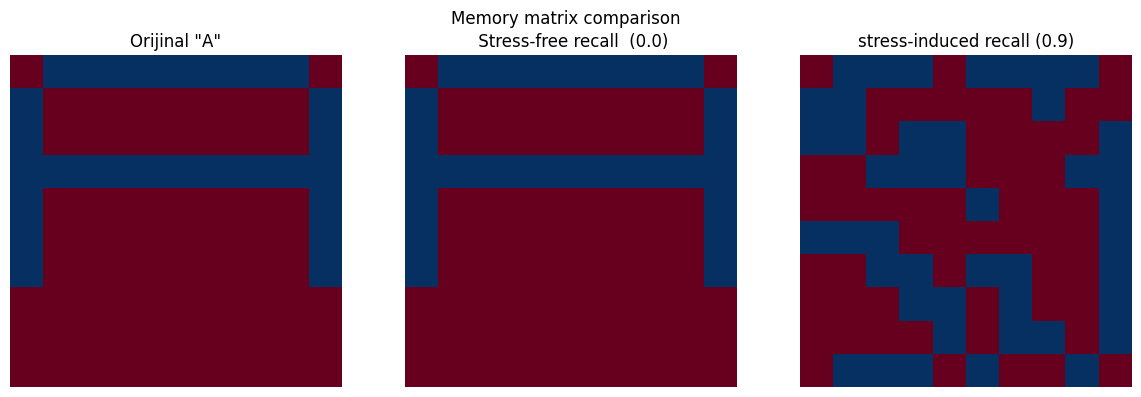

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original
axes[0].imshow(x.reshape(10, 10), cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_title('Original "A"')
axes[0].axis('off')

# Without stress
axes[1].imshow(memory_results[0.0], cmap='RdBu', vmin=-1, vmax=1)
axes[1].set_title(' Stress-free recall  (0.0)')
axes[1].axis('off')

#With stress
axes[2].imshow(memory_results[0.9], cmap='RdBu', vmin=-1, vmax=1)
axes[2].set_title('stress-induced recall (0.9)')
axes[2].axis('off')

plt.suptitle('Memory matrix comparison  ')
plt.tight_layout()
plt.show()

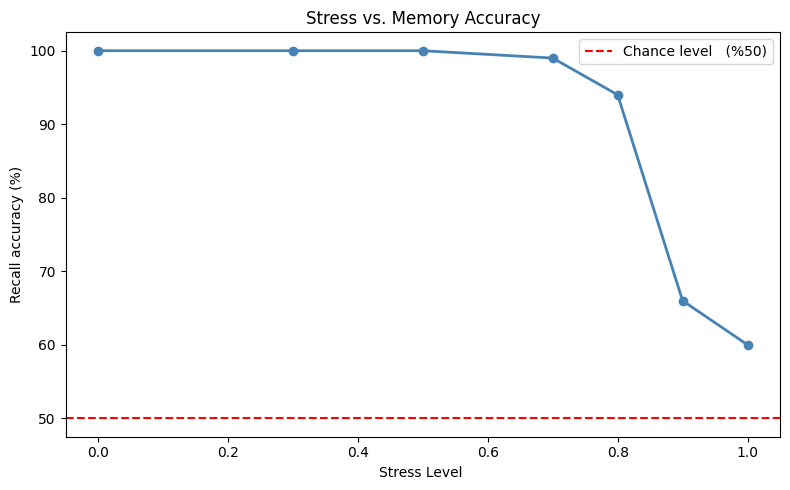

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(stresslevels, accuracy_list, marker='o', color='steelblue', linewidth=2)
plt.axhline(y=50, color='red', linestyle='--', label='Chance level   (%50)')
plt.xlabel('Stress Level ')
plt.ylabel('Recall accuracy (%)')
plt.title('Stress vs. Memory Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
new_accuracy_list=[]
W_stress=w_dict[0.7]
for k in range(5,100,5):
    sum=0
    for l in range(10):
        clue=x*-1
        correct_index=np.random.choice(N,k,replace=False)
        clue[correct_index]=x[correct_index]
        for i in range(20):
            clue_new = np.sign(W_stress @ clue)
            clue_new[clue_new == 0] = 1
            if np.array_equal(clue_new, clue):
                break
            clue = clue_new
        accuracy=np.sum(x==clue)/N*100
        memory_results[i]=clue.reshape(10,10)
        sum+=accuracy
    sum=sum/10

    new_accuracy_list.append(sum)
    print(f"accuracy {k}:{accuracy:.1f}%"  )


accuracy 5:1.0%
accuracy 10:1.0%
accuracy 15:1.0%
accuracy 20:1.0%
accuracy 25:1.0%
accuracy 30:1.0%
accuracy 35:1.0%
accuracy 40:1.0%
accuracy 45:1.0%
accuracy 50:99.0%
accuracy 55:99.0%
accuracy 60:99.0%
accuracy 65:99.0%
accuracy 70:99.0%
accuracy 75:99.0%
accuracy 80:99.0%
accuracy 85:99.0%
accuracy 90:99.0%
accuracy 95:99.0%


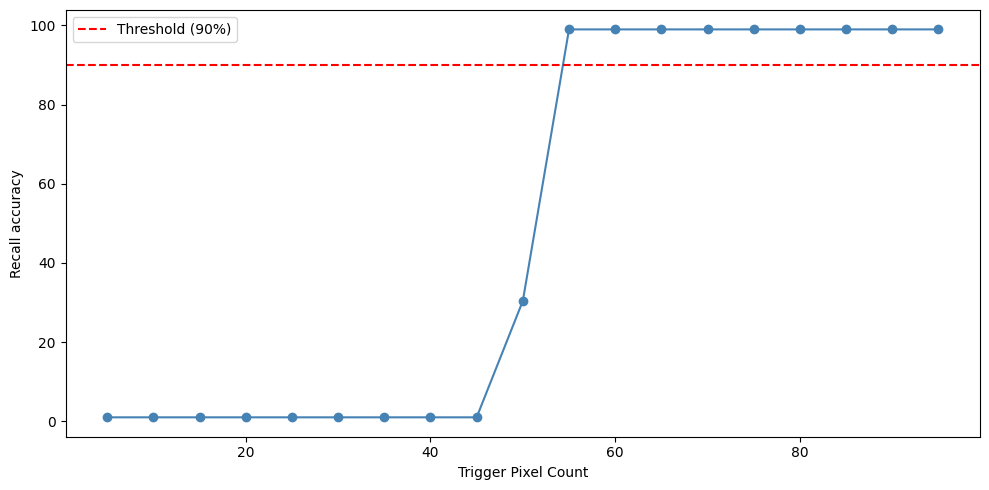

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(range(5, 100, 5), new_accuracy_list, marker='o', color='steelblue')
plt.axhline(y=90, color='red', linestyle='--', label='Threshold (90%)')
plt.xlabel('Trigger Pixel Count')
plt.ylabel('Recall accuracy')
plt.legend()
plt.tight_layout()
plt.show()